
# 🧠 Convolutional Neural Networks (CNN) - Beginner Friendly

## 🎯 What you will learn:
- Why CNN is used for images
- Convolution (simple idea)
- Filters and Pooling
- Train a CNN model

💡 Focus on understanding, not math.


In [1]:

!pip install tensorflow matplotlib


In [2]:

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt



## 📂 Load Dataset (CIFAR-10)


In [3]:

(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

train_images, test_images = train_images / 255.0, test_images / 255.0

print(train_images.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
(50000, 32, 32, 3)



## 🖼️ Show Sample Images


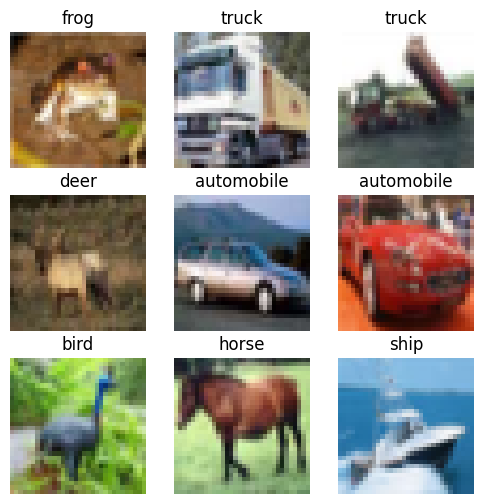

In [4]:

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(train_images[i])
    plt.title(class_names[train_labels[i][0]])
    plt.axis('off')



## 🏗️ Build CNN Model


In [5]:

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])



## 🚀 Train Model


In [7]:

history = model.fit(train_images, train_labels, epochs=3,
                    validation_data=(test_images, test_labels))


Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 51ms/step - accuracy: 0.4784 - loss: 1.4533 - val_accuracy: 0.5350 - val_loss: 1.3294
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 53ms/step - accuracy: 0.6117 - loss: 1.1070 - val_accuracy: 0.6406 - val_loss: 1.0500
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.6598 - loss: 0.9773 - val_accuracy: 0.6635 - val_loss: 0.9826



## 📊 Evaluate Model


In [8]:

test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Test accuracy:", test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6635 - loss: 0.9826
Test accuracy: 0.6635000109672546



## 🔍 Prediction


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

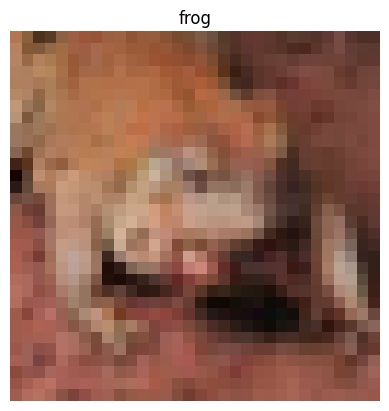

In [9]:

import numpy as np

predictions = model.predict(test_images)

index = 5
plt.imshow(test_images[index])
plt.title(class_names[np.argmax(predictions[index])])
plt.axis('off')



## 🎯 Task
- Change epochs to 5
- Modify filters
- Observe accuracy


1. Change Epochs to 5

In [10]:
# Train model with more epochs

history = model.fit(
    train_images, train_labels,
    epochs=5,   # changed from 3 → 5
    validation_data=(test_images, test_labels)
)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 52ms/step - accuracy: 0.6921 - loss: 0.8934 - val_accuracy: 0.6492 - val_loss: 1.0188
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.7126 - loss: 0.8306 - val_accuracy: 0.6900 - val_loss: 0.9133
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 49ms/step - accuracy: 0.7282 - loss: 0.7808 - val_accuracy: 0.6868 - val_loss: 0.9113
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.7457 - loss: 0.7310 - val_accuracy: 0.6971 - val_loss: 0.9063
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 53ms/step - accuracy: 0.7610 - loss: 0.6874 - val_accuracy: 0.6891 - val_loss: 0.9527


2. Modify Filters (IMPORTANT CONCEPT)

Increase Filters

In [11]:
model = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),  # increased from 32 → 64
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),  # increased from 64 → 128
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

Reduce Filters

In [12]:
model = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(32,32,3)),  # reduced
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(10)
])

In [15]:
# IMPORTANT: Compile again after modifying model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

3. Observe Accuracy

In [16]:
# Evaluate model
test_loss, test_acc = model.evaluate(test_images, test_labels)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.1024 - loss: 2.3562
Test Accuracy: 0.10239999741315842


Bonus

Plot accuracy graph:

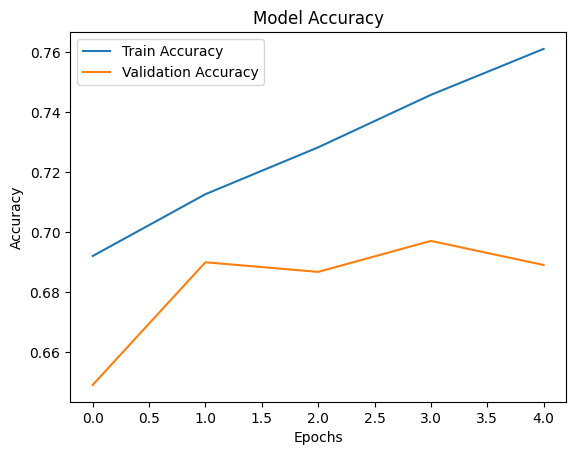

In [17]:
# Plot training vs validation accuracy

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

“Did accuracy increase or decrease?”

“What happened when filters increased?”

“Did more epochs always improve results?”